In [11]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 2ab22ca Add classification results for all 5 transform strategies


In [12]:
# # Uncomment to clear cached results and force regeneration
# import os
# results_dir = "/workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2"
# for f in [
#     "legible_attention_entropy.npy",
#     "illegible_attention_entropy.npy",
#     "attention_results.json",
#     "a3_attention_entropy.png",
#     "a3_attention_heatmap.png",
# ]:
#     path = os.path.join(results_dir, f)
#     if os.path.exists(path):
#         os.remove(path)
#         print(f"Removed {path}")
# print("Cache cleared -- re-run all cells to regenerate")

# NB5: Attention Pattern Analysis (Experiment A3)

**GPU notebook** (~1 hour). Reload G3, run forward pass with `output_attentions=True`
on legible vs illegible CoTs. Compare attention entropy per head per layer.

Hypothesis: legible CoTs have more concentrated attention patterns (focused on
specific reasoning steps), while illegible CoTs have more diffuse attention.

**Requires:** `results/classifications.json`, Step 1 generation logs

In [13]:
import sys
import json
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    join_cots_with_labels, load_model, bootstrap_ci_metric,
    PHASE2_RESULTS_DIR, LOCAL_MODELS,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"CUDA: {torch.cuda.is_available()}")

CUDA: True


In [14]:
# Load legible + illegible CoTs for G3
cots = join_cots_with_labels(
    labels=['REASONING_LEGIBLE', 'ILLEGIBLE'],
    generator_ids=['G3'],
)
cots = sorted(cots, key=lambda x: (x['sample_id'], x['epoch']))

legible = [c for c in cots if c['label'] == 'REASONING_LEGIBLE']
illegible = [c for c in cots if c['label'] == 'ILLEGIBLE']
print(f"Legible: {len(legible)}, Illegible: {len(illegible)}")

# Limit to manageable sample size (attention tensors are large)
MAX_SAMPLES = 50
legible_sample = legible[:MAX_SAMPLES]
illegible_sample = illegible[:MAX_SAMPLES]
print(f"Using: {len(legible_sample)} legible, {len(illegible_sample)} illegible")

Legible: 30, Illegible: 126
Using: 30 legible, 50 illegible


In [15]:
# Check if attention entropy arrays already exist (skip model load if so)
_leg_entropy_path = PHASE2_RESULTS_DIR / 'legible_attention_entropy.npy'
_ill_entropy_path = PHASE2_RESULTS_DIR / 'illegible_attention_entropy.npy'
_entropy_cached = _leg_entropy_path.exists() and _ill_entropy_path.exists()

if _entropy_cached:
    print("CACHED: Attention entropy arrays exist, skipping G3 model load")
    model = tokenizer = None
    n_layers = n_heads = None
else:
    # Load G3 with eager attention (required for output_attentions=True)
    # SDPA doesn't support returning attention weights
    from transformers import AutoModelForCausalLM, AutoTokenizer
    hf_id = LOCAL_MODELS["G3"]["hf_id"]
    local_path = LOCAL_MODELS["G3"].get("local_path", hf_id)
    print(f"Loading {hf_id} with attn_implementation='eager'...")
    tokenizer = AutoTokenizer.from_pretrained(local_path, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        local_path,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
        attn_implementation="eager",
    )
    model.eval()
    n_layers = model.config.num_hidden_layers
    n_heads = model.config.num_attention_heads
    print(f"Layers: {n_layers}, Heads: {n_heads}")

Loading Qwen/QwQ-32B with attn_implementation='eager'...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/771 [00:00<?, ?it/s]

Layers: 64, Heads: 40


In [16]:
if _entropy_cached:
    print(f"CACHED: Loading pre-computed attention entropy arrays")
    legible_entropy = np.load(_leg_entropy_path)
    illegible_entropy = np.load(_ill_entropy_path)
    print(f"Legible entropy shape: {legible_entropy.shape}")
    print(f"Illegible entropy shape: {illegible_entropy.shape}")
else:
    def compute_attention_entropy(model, tokenizer, texts, max_length=4096):
        """Compute per-head attention entropy for each text.
        
        Returns: array of shape (n_texts, n_layers, n_heads) with mean entropy per head.
        Also returns sequence lengths for normalization.
        """
        device = next(model.parameters()).device
        all_entropies = []
        seq_lengths = []
        
        for text in tqdm(texts, desc="Computing attention entropy"):
            inputs = tokenizer(
                text, return_tensors="pt", truncation=True, max_length=max_length
            ).to(device)
            
            seq_len = inputs["attention_mask"].sum().item()
            seq_lengths.append(seq_len)
            
            with torch.no_grad():
                outputs = model(**inputs, output_attentions=True)
            
            # Check that attentions were actually returned
            if not outputs.attentions or len(outputs.attentions) == 0:
                raise RuntimeError(
                    "Model returned no attention weights. Ensure the model was loaded "
                    "with attn_implementation='eager' (SDPA does not support output_attentions)."
                )
            
            # outputs.attentions is tuple of (1, n_heads, seq_len, seq_len) per layer
            layer_entropies = []
            for layer_attn in outputs.attentions:
                # layer_attn: (1, n_heads, seq_len, seq_len)
                attn = layer_attn[0]  # (n_heads, seq_len, seq_len)
                
                # Compute entropy for each head: -sum(p * log(p)) averaged over query positions
                # Clamp to avoid log(0)
                attn_clamped = attn.clamp(min=1e-10)
                entropy = -(attn_clamped * attn_clamped.log()).sum(dim=-1)  # (n_heads, seq_len)
                mean_entropy = entropy.mean(dim=-1)  # (n_heads,)
                layer_entropies.append(mean_entropy.cpu().float().numpy())
            
            all_entropies.append(np.stack(layer_entropies, axis=0))  # (n_layers, n_heads)
            
            del outputs
            torch.cuda.empty_cache()
        
        return np.array(all_entropies), np.array(seq_lengths)  # (n_texts, n_layers, n_heads), (n_texts,)

    # Process one sample at a time (attention tensors: n_heads x seq_len x seq_len)
    print("Processing legible CoTs...")
    legible_entropy, legible_seq_lens = compute_attention_entropy(
        model, tokenizer, [c['cot_text'] for c in legible_sample], max_length=4096
    )

    print("Processing illegible CoTs...")
    illegible_entropy, illegible_seq_lens = compute_attention_entropy(
        model, tokenizer, [c['cot_text'] for c in illegible_sample], max_length=4096
    )

    print(f"Legible entropy shape: {legible_entropy.shape}")
    print(f"Illegible entropy shape: {illegible_entropy.shape}")
    print(f"Legible seq lengths: mean={legible_seq_lens.mean():.0f}, "
          f"std={legible_seq_lens.std():.0f}")
    print(f"Illegible seq lengths: mean={illegible_seq_lens.mean():.0f}, "
          f"std={illegible_seq_lens.std():.0f}")

Processing legible CoTs...


Computing attention entropy: 100%|██████████| 30/30 [00:03<00:00,  8.65it/s]


Processing illegible CoTs...


Computing attention entropy: 100%|██████████| 50/50 [00:05<00:00,  8.71it/s]

Legible entropy shape: (30, 64, 40)
Illegible entropy shape: (50, 64, 40)
Legible seq lengths: mean=467, std=171
Illegible seq lengths: mean=524, std=207


Legible mean seq_len: 467
Illegible mean seq_len: 524


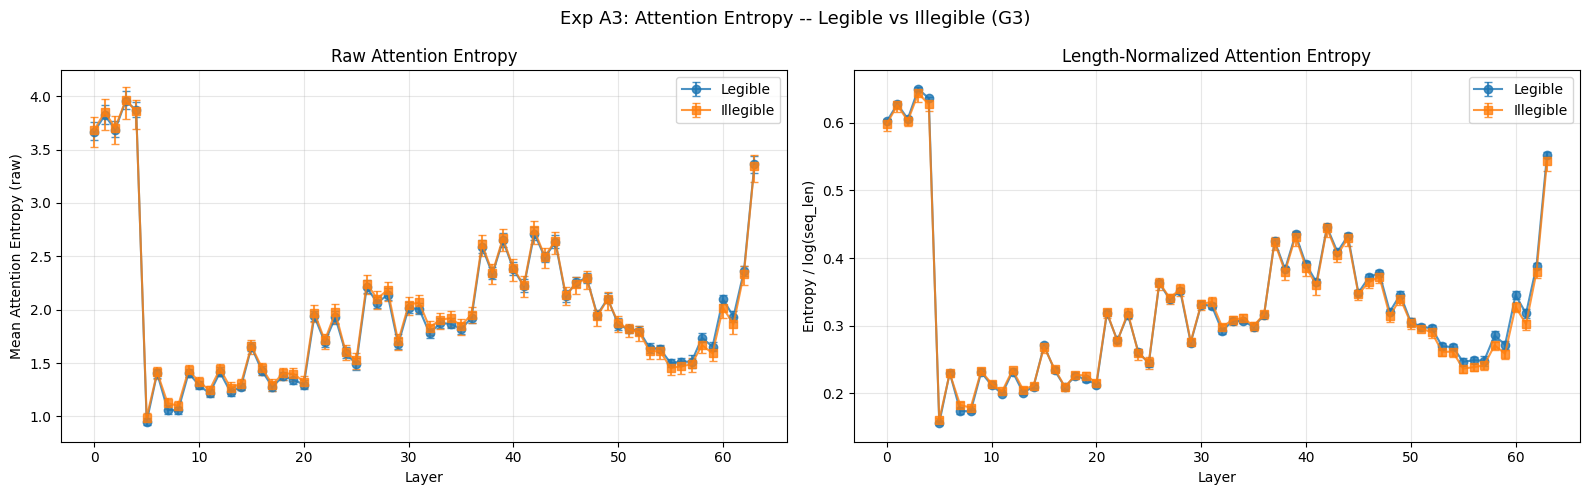

In [17]:
# Compare mean entropy per layer between legible and illegible
# Report BOTH raw and length-normalized entropy

# --- Raw entropy ---
leg_mean_per_layer = legible_entropy.mean(axis=(0, 2))  # (n_layers,)
ill_mean_per_layer = illegible_entropy.mean(axis=(0, 2))  # (n_layers,)

# --- Length-normalized entropy ---
# Normalize each sample's entropy by log(seq_len) to control for
# the confound that longer sequences naturally have higher entropy.
# If cached (no seq_lengths available), attempt to load from saved results.
if 'legible_seq_lens' not in dir() or 'illegible_seq_lens' not in dir():
    # Fallback: load from saved results if available
    _attn_json = PHASE2_RESULTS_DIR / 'attention_results.json'
    if _attn_json.exists():
        with open(_attn_json) as f:
            _attn_saved = json.load(f)
        legible_seq_lens = np.array(_attn_saved.get('legible_seq_lengths', []))
        illegible_seq_lens = np.array(_attn_saved.get('illegible_seq_lengths', []))
    if len(legible_seq_lens) == 0 or len(illegible_seq_lens) == 0:
        # Cannot normalize without sequence lengths; use raw only
        print("WARNING: Sequence lengths not available, using raw entropy only")
        legible_seq_lens = np.ones(legible_entropy.shape[0])
        illegible_seq_lens = np.ones(illegible_entropy.shape[0])

# Normalize: divide each sample's entropy by log(seq_len)
leg_norm_factor = np.log(legible_seq_lens).clip(min=1.0)[:, None, None]  # (n_texts, 1, 1)
ill_norm_factor = np.log(illegible_seq_lens).clip(min=1.0)[:, None, None]
leg_normalized = legible_entropy / leg_norm_factor
ill_normalized = illegible_entropy / ill_norm_factor

leg_norm_per_layer = leg_normalized.mean(axis=(0, 2))
ill_norm_per_layer = ill_normalized.mean(axis=(0, 2))

print(f"Legible mean seq_len: {legible_seq_lens.mean():.0f}")
print(f"Illegible mean seq_len: {illegible_seq_lens.mean():.0f}")

# Bootstrap CI per layer (raw)
leg_ci = []
ill_ci = []
for l in range(legible_entropy.shape[1]):
    _, lo, hi = bootstrap_ci_metric(legible_entropy[:, l, :].mean(axis=1))
    leg_ci.append((lo, hi))
    _, lo, hi = bootstrap_ci_metric(illegible_entropy[:, l, :].mean(axis=1))
    ill_ci.append((lo, hi))

# Bootstrap CI per layer (normalized)
leg_norm_ci = []
ill_norm_ci = []
for l in range(leg_normalized.shape[1]):
    _, lo, hi = bootstrap_ci_metric(leg_normalized[:, l, :].mean(axis=1))
    leg_norm_ci.append((lo, hi))
    _, lo, hi = bootstrap_ci_metric(ill_normalized[:, l, :].mean(axis=1))
    ill_norm_ci.append((lo, hi))

# Plot both raw and normalized
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
layers = range(len(leg_mean_per_layer))

# Raw entropy
leg_yerr = [[leg_mean_per_layer[l] - leg_ci[l][0] for l in layers],
            [leg_ci[l][1] - leg_mean_per_layer[l] for l in layers]]
ill_yerr = [[ill_mean_per_layer[l] - ill_ci[l][0] for l in layers],
            [ill_ci[l][1] - ill_mean_per_layer[l] for l in layers]]

ax1.errorbar(list(layers), leg_mean_per_layer, yerr=leg_yerr,
            fmt='o-', capsize=3, label='Legible', alpha=0.8)
ax1.errorbar(list(layers), ill_mean_per_layer, yerr=ill_yerr,
            fmt='s-', capsize=3, label='Illegible', alpha=0.8)
ax1.set_xlabel('Layer')
ax1.set_ylabel('Mean Attention Entropy (raw)')
ax1.set_title('Raw Attention Entropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Normalized entropy
leg_norm_yerr = [[leg_norm_per_layer[l] - leg_norm_ci[l][0] for l in layers],
                 [leg_norm_ci[l][1] - leg_norm_per_layer[l] for l in layers]]
ill_norm_yerr = [[ill_norm_per_layer[l] - ill_norm_ci[l][0] for l in layers],
                 [ill_norm_ci[l][1] - ill_norm_per_layer[l] for l in layers]]

ax2.errorbar(list(layers), leg_norm_per_layer, yerr=leg_norm_yerr,
            fmt='o-', capsize=3, label='Legible', alpha=0.8)
ax2.errorbar(list(layers), ill_norm_per_layer, yerr=ill_norm_yerr,
            fmt='s-', capsize=3, label='Illegible', alpha=0.8)
ax2.set_xlabel('Layer')
ax2.set_ylabel('Entropy / log(seq_len)')
ax2.set_title('Length-Normalized Attention Entropy')
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle('Exp A3: Attention Entropy -- Legible vs Illegible (G3)', fontsize=13)
fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'a3_attention_entropy.png'), dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Identify heads with largest legible-illegible entropy difference
# Apply Benjamini-Hochberg FDR correction for multiple comparisons
# (64 layers x 64 heads = 4096 tests)
from scipy import stats

diff = legible_entropy.mean(axis=0) - illegible_entropy.mean(axis=0)  # (n_layers, n_heads)

# Compute per-head t-test p-values
n_layers_attn, n_heads_attn = diff.shape
p_values = np.zeros_like(diff)
t_stats = np.zeros_like(diff)

for l in range(n_layers_attn):
    for h in range(n_heads_attn):
        leg_vals = legible_entropy[:, l, h]
        ill_vals = illegible_entropy[:, l, h]
        t_stat, p_val = stats.ttest_ind(leg_vals, ill_vals)
        p_values[l, h] = p_val
        t_stats[l, h] = t_stat

# Benjamini-Hochberg FDR correction
flat_p = p_values.flatten()
n_tests = len(flat_p)
sorted_idx = np.argsort(flat_p)
sorted_p = flat_p[sorted_idx]

# BH threshold: p_(i) <= (i/m) * alpha
alpha_fdr = 0.05
bh_threshold = np.arange(1, n_tests + 1) / n_tests * alpha_fdr
rejected = sorted_p <= bh_threshold

# Find the largest k where rejection holds
if rejected.any():
    max_rejected = np.max(np.where(rejected)[0])
    fdr_threshold = sorted_p[max_rejected]
    significant_mask = flat_p <= fdr_threshold
    n_significant = significant_mask.sum()
else:
    fdr_threshold = 0.0
    significant_mask = np.zeros(n_tests, dtype=bool)
    n_significant = 0

significant_mask_2d = significant_mask.reshape(n_layers_attn, n_heads_attn)

print(f"Multiple comparison correction (Benjamini-Hochberg, alpha={alpha_fdr}):")
print(f"  Total tests: {n_tests}")
print(f"  Significant after FDR: {n_significant}")
print(f"  FDR threshold p-value: {fdr_threshold:.6f}")

if n_significant > 0:
    print(f"\nSignificant heads (FDR-corrected, alpha={alpha_fdr}):")
    print(f"{'Layer':>6} {'Head':>6} {'Diff':>8} {'p-value':>10} {'t-stat':>8}")
    sig_indices = np.argwhere(significant_mask_2d)
    # Sort by absolute difference
    sig_indices = sorted(sig_indices, key=lambda x: abs(diff[x[0], x[1]]), reverse=True)
    for idx in sig_indices:
        l, h = idx[0], idx[1]
        print(f"{l:>6} {h:>6} {diff[l, h]:>+8.4f} {p_values[l, h]:>10.6f} {t_stats[l, h]:>8.2f}")
else:
    print("\nNo heads survive FDR correction.")
    print("Top 10 heads by |entropy difference| (uncorrected, for reference only):")
    print(f"{'Layer':>6} {'Head':>6} {'Diff':>8} {'p-value':>10} {'Leg Ent':>10} {'Ill Ent':>10}")
    flat_idx = np.argsort(np.abs(diff).flatten())[::-1]
    for i in range(min(10, len(flat_idx))):
        layer = flat_idx[i] // diff.shape[1]
        head = flat_idx[i] % diff.shape[1]
        print(f"{layer:>6} {head:>6} {diff[layer, head]:>+8.4f} {p_values[layer, head]:>10.6f} "
              f"{legible_entropy[:, layer, head].mean():>10.4f} "
              f"{illegible_entropy[:, layer, head].mean():>10.4f}")
    print("  (None survive FDR correction -- these are likely noise)")

Multiple comparison correction (Benjamini-Hochberg, alpha=0.05):
  Total tests: 2560
  Significant after FDR: 0
  FDR threshold p-value: 0.000000

No heads survive FDR correction.
Top 10 heads by |entropy difference| (uncorrected, for reference only):
 Layer   Head     Diff    p-value    Leg Ent    Ill Ent
    58     33  +0.3836   0.002325     3.2516     2.8680
    52     29  +0.3174   0.000973     2.3729     2.0555
    31     34  -0.3001   0.008363     2.3826     2.6827
    58     31  +0.2874   0.001071     2.0378     1.7504
    50     16  -0.2725   0.034301     1.2465     1.5190
    31     31  -0.2678   0.001218     1.3007     1.5684
     8      5  -0.2423   0.009557     1.5995     1.8418
    32      9  -0.2405   0.007571     1.3315     1.5720
    60      6  +0.2335   0.001312     1.7271     1.4936
    31     15  -0.2281   0.007303     1.5069     1.7350
  (None survive FDR correction -- these are likely noise)


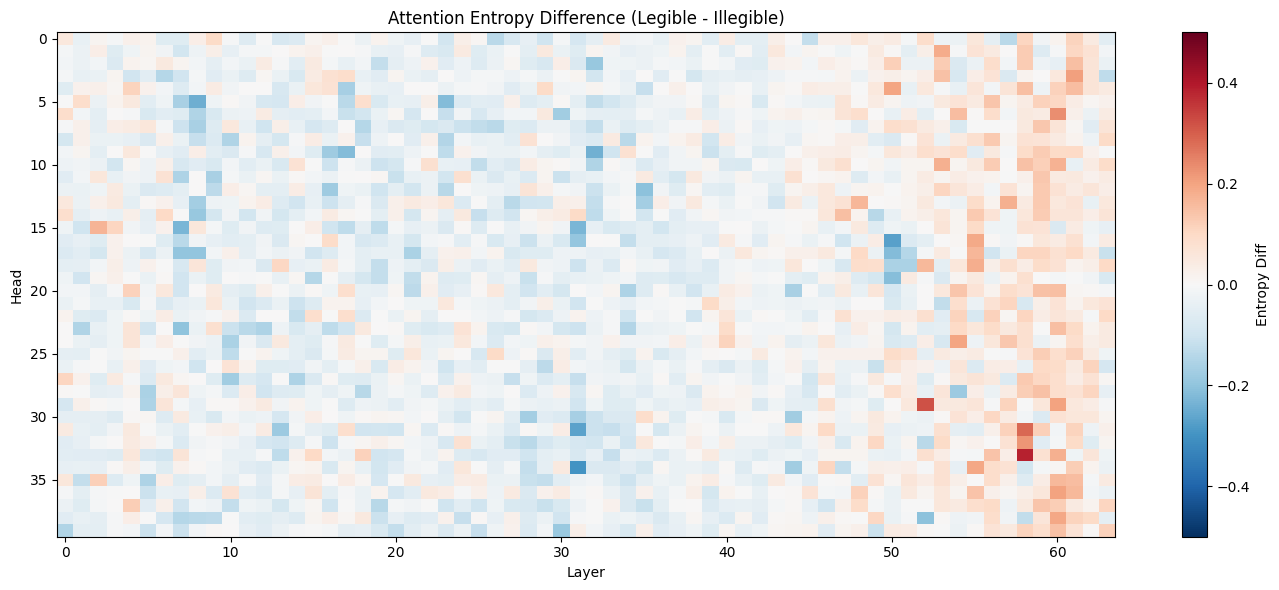


Foreignness covariate check:
  Foreignness data not available


In [19]:
# Heatmap of entropy difference across layers and heads
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(diff.T, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
ax.set_xlabel('Layer')
ax.set_ylabel('Head')
ax.set_title('Attention Entropy Difference (Legible - Illegible)')
plt.colorbar(im, ax=ax, label='Entropy Diff')
fig.tight_layout()
fig.savefig(str(PHASE2_RESULTS_DIR / 'a3_attention_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Foreignness covariate check ---
from phase2_utils import load_foreignness_scores
foreignness = load_foreignness_scores()

leg_f_scores = []
for c in legible_sample:
    scores = []
    for rid in ['R1', 'R2', 'R3']:
        key = (c['sample_id'], c['generator_id'], c['epoch'], rid)
        if key in foreignness:
            scores.append(foreignness[key])
    leg_f_scores.append(np.mean(scores) if scores else np.nan)

ill_f_scores = []
for c in illegible_sample:
    scores = []
    for rid in ['R1', 'R2', 'R3']:
        key = (c['sample_id'], c['generator_id'], c['epoch'], rid)
        if key in foreignness:
            scores.append(foreignness[key])
    ill_f_scores.append(np.mean(scores) if scores else np.nan)

leg_f_scores = np.array(leg_f_scores)
ill_f_scores = np.array(ill_f_scores)

print("\nForeignness covariate check:")
if np.isfinite(leg_f_scores).any() and np.isfinite(ill_f_scores).any():
    print(f"  Legible:   mean={np.nanmean(leg_f_scores):.2f}, std={np.nanstd(leg_f_scores):.2f}")
    print(f"  Illegible: mean={np.nanmean(ill_f_scores):.2f}, std={np.nanstd(ill_f_scores):.2f}")
    from scipy import stats as sp_stats
    t_stat, p_val = sp_stats.ttest_ind(
        leg_f_scores[np.isfinite(leg_f_scores)],
        ill_f_scores[np.isfinite(ill_f_scores)]
    )
    print(f"  t-test: t={t_stat:.2f}, p={p_val:.4f}")
else:
    print("  Foreignness data not available")

In [20]:
# Save results and cleanup
results = {
    'legible_mean_entropy_per_layer': leg_mean_per_layer.tolist(),
    'illegible_mean_entropy_per_layer': ill_mean_per_layer.tolist(),
    'legible_norm_entropy_per_layer': leg_norm_per_layer.tolist(),
    'illegible_norm_entropy_per_layer': ill_norm_per_layer.tolist(),
    'legible_entropy_ci_per_layer': [list(ci) for ci in leg_ci],
    'illegible_entropy_ci_per_layer': [list(ci) for ci in ill_ci],
    'legible_norm_ci_per_layer': [list(ci) for ci in leg_norm_ci],
    'illegible_norm_ci_per_layer': [list(ci) for ci in ill_norm_ci],
    'entropy_diff_shape': list(diff.shape),
    'n_legible': len(legible_sample),
    'n_illegible': len(illegible_sample),
    'fdr_n_significant': int(n_significant),
    'fdr_alpha': alpha_fdr,
    'fdr_threshold': float(fdr_threshold),
}

# Save sequence lengths if available
if 'legible_seq_lens' in dir() and len(legible_seq_lens) > 0:
    results['legible_seq_lengths'] = legible_seq_lens.tolist()
    results['illegible_seq_lengths'] = illegible_seq_lens.tolist()

with open(PHASE2_RESULTS_DIR / 'attention_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save the full entropy arrays for later analysis
np.save(PHASE2_RESULTS_DIR / 'legible_attention_entropy.npy', legible_entropy)
np.save(PHASE2_RESULTS_DIR / 'illegible_attention_entropy.npy', illegible_entropy)

if model is not None:
    del model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("NB5 complete.")

NB5 complete.
